# **Project : A Case Study of ExpressWay Logistics**

**Business Overview:**

ExpressWay Logistics is a dynamic logistics service provider, committed to delivering efficient, reliable and cost-effective courier transportation and warehousing solutions. With a focus on speed, precision and customer satisfaction, we aim to be the go-to partner for our customers seeking seamless courier services. Our core service involves ensuring operational efficiency throughout our delivery and courier services, including inventory management, durable packaging and swift dispatch of couriers, real time tracking of shipments and on-time delivery of couriers as promised. We are committed to enhance our logistics and courier services and improve seamless connectivity for our customers.

**Current Challenge:**

ExpressWay Logistics faces numerous challenges in ensuring seamless deliveries and customer satisfaction. These challenges include managing various customer demands simultaneously, addressing delays in deliveries and ensuring products arrive intact and safe. Additionally, the company struggles with complexity of efficiently storing and handling a large volume of packages and ultimately meeting customer expectations. Moreover, maintaining a skilled workforce capable of handling various aspects of logistics operations presents its own set of challenges. Overcoming these obstacles requires a comprehensive approach that integrates innovative technology, strategic planning, and continuous improvement initiatives to ensure smooth operations and exceptional service delivery.

**Objective:**

Our primary objective is to conduct a sentiment analysis of user-generated reviews across various digital channels and platforms. By paying attention to their feedback, we want to find ways to make our services better - like handling different customer demands simultaneously, dealing with late deliveries, and keeping packages secured and intact. Through the application of prompt engineering methodologies and sentiment analysis, we'll figure out if sentiments expressed by users for our courier services are Positive or Negative. This will help us understand where we need to improve in order to meet customer expectations and keep them happy. With a focus on getting better all the time, we'll overcome the challenges at ExpressWay Logistics and make our services the best.

**Data Description:**

The dataset titled "courier-service_reviews.csv" is structured to facilitate sentiment analysis for courier service reviews. Here's a brief description of the data columns:

1. id: This column contains unique identifiers for each review entry. It helps in distinguishing and referencing individual reviews.
2. review: This column includes the actual text of the courier service reviews. The reviews are likely composed of customer opinions and experiences regarding different aspects of the services provided by ExpressWay Logistics.
3. sentiment: This column provides an additional layer of classification (positive and negative) for the mentioned reviews.

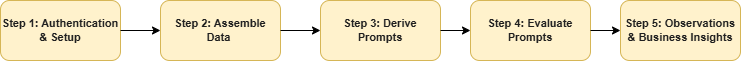

### Installation

In [ ]:
!pip install -q google-generativeai tiktoken datasets session-info --quiet


### Imports

In [ ]:
# Import all Python packages required to access the Google Gemini API.
# Import additional packages required to access datasets and create examples.

import google.generativeai as genai
import json
import random
import tiktoken
import session_info

import pandas as pd
import numpy as np

from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tabulate import tabulate


In [ ]:
#session_info.show()

### API Setup


In [ ]:
!pip install groq

In [ ]:
config_data = {
    "GROQ_API_KEY": "YOUR_GROQ_API_KEY_HERE", # get from https://groq.com
    "GROQ_MODEL": "llama-3.1-8b-instant"   # free and fast
}

In [ ]:

with open('config.json', 'w') as config_file:
    json.dump(config_data, config_file, indent=4)

print("Config file created successfully!")


In [ ]:
with open('config.json', 'r') as gem_creds:
    data = gem_creds.read()


In [ ]:
creds = json.loads(data)


In [ ]:
from groq import Groq
client = Groq(api_key=creds["GROQ_API_KEY"])

### Utilities

In [ ]:
def num_tokens_from_messages(messages):

    """
    Return the number of tokens used by a list of messages.
    Adapted from the Open AI cookbook token counter
    """

    encoding = tiktoken.encoding_for_model("gpt-4")

    # Each message is sandwiched with <|start|>role and <|end|>
    # Hence, messages look like: <|start|>system or user or assistant{message}<|end|>

    tokens_per_message = 3 # token1:<|start|>, token2:system(or user or assistant), token3:<|end|>

    num_tokens = 0

    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))

    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>

    return num_tokens

In [ ]:
import os
print(os.getcwd())

In [ ]:
cs_reviews_df = pd.read_csv("/Users/ashishgollamudy/Desktop/expressway/courier-service_reviews-1.csv")

In [ ]:
cs_reviews_df.info()

In [ ]:
cs_reviews_df.sample(5)

In [ ]:
cs_reviews_df.sentiment.value_counts()

In [ ]:
cs_reviews_df.shape

In [ ]:
cs_examples_df, cs_gold_examples_df = train_test_split(
    cs_reviews_df, #<- the full dataset
    test_size=0.2, #<- 20% random sample selected for gold examples
    random_state=42 #<- ensures that the splits are the same for every session
)

In [ ]:
(cs_examples_df.shape, cs_gold_examples_df.shape)

To select gold examples for this session, we sample randomly from the test data using a `random_state=42`. This ensures that the examples from multiple runs of the sampling are the same (i.e., they are randomly selected but do not change between different runs of the notebook). Note that we are doing this only to keep execution times low for illustration. In practise, large number of gold examples facilitate robust estimates of model accuracy.

In [ ]:
columns_to_select = ['review','sentiment']

In [ ]:
gold_examples = (
        cs_gold_examples_df.loc[:, columns_to_select]
                                     .sample(21, random_state=42) #<- ensures that gold examples are the same for every session
                                     .to_json(orient='records')
)

In [ ]:
gold_examples

In [ ]:
json.loads(gold_examples)[0]     #Json format

In [ ]:
user_message_template = """```{courier_service_review}```"""

**Zero Shot System Message**

In [ ]:
zero_shot_system_message = """Classify the following product review into one of the following sentiments:
Categories - ['Positive', 'Negative']
The review text will be delimited by triple backticks in the input.
Answer only 'Positive' or 'Negative'. Do not use any other labels and do not provide any explanations."""
# Write zero shot system message here

**Zero Shot Prompt**

In [ ]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]


In [ ]:
num_tokens_from_messages(zero_shot_prompt)

**Few Shot System Message**

In [ ]:
few_shot_system_message = """Classify the following product review into one of the following sentiments:
Categories - ['Positive', 'Negative']
The review text will be delimited by triple backticks in the input.
Answer only 'Positive' or 'Negative'. Do not use any other labels and do not provide any explanations."""

Merely selecting random samples from the polarity subsets is not enough because the examples included in a prompt are prone to a set of known biases such as:
 - Majority label bias (frequent answers in predictions)
 - Recency bias (examples near the end of the prompt)


To avoid these biases, it is important to have a balanced set of examples that are arranged in random order. Let us create a Python function that generates bias-free examples:

```create_examples``` function generates a randomized set of example reviews with equal representation from two sentiment classes: Positive and Negative. It first filters the dataset into two separate groups based on sentiment labels. Then, it randomly selects `n` examples from each class and combines them into a single dataset. The combined examples are shuffled to ensure randomness before being converted into a JSON format. Each time the function runs, it produces a different set of randomized examples from the dataset.

In [ ]:
def create_examples(dataset, n=4):

    """
    Return a JSON list of randomized examples of size 2n with two classes.
    Create subsets of each class, choose random samples from the subsets,
    merge and randomize the order of samples in the merged list.
    Each run of this function creates a different random sample of examples
    chosen from the training data.

    Args:
        dataset (DataFrame): A DataFrame with examples (review + label)
        n (int): number of examples of each class to be selected

    Output:
        randomized_examples (JSON): A JSON with examples in random order
    """

    positive_reviews = (dataset.sentiment == 'Positive')
    negative_reviews = (dataset.sentiment == 'Negative')
    columns_to_select = ['review', 'sentiment']

    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)

    examples = pd.concat([positive_examples, negative_examples])

    # sampling without replacement is equivalent to random shuffling

    randomized_examples = examples.sample(2*n, replace=False)

    return randomized_examples.to_json(orient='records')

**Create Examples For Few shot prompte**

In [ ]:
examples = create_examples(cs_examples_df, 2)
# Create Examples

In [ ]:
json.loads(examples)

With the examples in place, we can now assemble a few-shot prompt. Since we will be using the few-shot prompt several times during evaluation, let us write a function to create a few-shot prompt (the logic of this function is depicted below).

create_prompt function constructs a few-shot prompt formatted for the OpenAI API, incorporating system instructions, example interactions, and a user message template. It starts by adding the system message, which provides guidelines for sentiment analysis. Then, it loops through the provided examples, formatting each review as a user message and its corresponding sentiment as an assistant response. These are appended to the prompt list in the required sequence. The final output is a structured list of dictionaries that can be directly used as input for an OpenAI model.

In [ ]:
def create_prompt(system_message, examples, user_message_template):

    """
    Return a prompt message in the format expected by the Open AI API.
    Loop through the examples and parse them as user message and assistant
    message.

    Args:
        system_message (str): system message with instructions for sentiment analysis
        examples (str): JSON string with list of examples
        user_message_template (str): string with a placeholder for courier service reviews

    Output:
        few_shot_prompt (List): A list of dictionaries in the Open AI prompt format
    """

    few_shot_prompt = [{'role':'system', 'content': system_message}]

    for example in json.loads(examples):
        example_review = example['review']
        example_sentiment = example['sentiment']

        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    courier_service_review=example_review
                )
            }
        )

        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )

    return few_shot_prompt

**Create Few Shot Prompt**

In [ ]:
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)

# Create Few shot prompt

In [ ]:
few_shot_prompt

In [ ]:
num_tokens_from_messages(few_shot_prompt)

Now we have two sets of prompts that we need to evaluate using gold labels. Since the few-shot prompt depends on the sample of examples that was drawn to make up the prompt, we expect some variability in evaluation. Hence, we evaluate each prompt multiple times to get a sense of the average and the variation around the average.

To reiterate, a choice on the prompt should account for variability due to the choice of the random sample. To aid repeated evaluation, we assemble an evaluation function .

The ```evaluate_prompt``` function evaluates the performance of a sentiment analysis model using a micro-F1 score by comparing its predictions to gold-standard examples. It iterates through gold examples, formats each review into a user input message, and appends it to the provided prompt. The prompt is then sent to the OpenAI model for prediction, ensuring deterministic outputs by setting a low temperature and restricting the token limit. The predicted sentiments are collected alongside ground truth labels for evaluation. Finally, the function calculates and prints the micro-F1 score while displaying a comparison table of reviews, predictions, and actual labels.









In [ ]:
def evaluate_prompt(prompt, gold_examples, user_message_template):

    """
    Return the micro-F1 score for predictions on gold examples.
    For each example, we make a prediction using the prompt. Gold labels and
    model predictions are aggregated into lists and compared to compute the
    F1 score.

    Args:
        prompt (List): list of messages in the OpenAI-style prompt format
        gold_examples (str): JSON string with list of gold examples
        user_message_template (str): string with a placeholder for courier service review

    Output:
        micro_f1_score (float): Micro-F1 score computed by comparing model predictions
                                with ground truth
    """

    model_predictions, ground_truths, review_texts = [], [], []

    for example in json.loads(gold_examples):
        gold_input = example['review']

        # Build full prompt text from messages list
        full_prompt = ""
        for msg in prompt:
            role = msg['role'].upper()
            content = msg['content']
            full_prompt += f"{role}: {content}\n"

        # Add the user review
        user_input = user_message_template.format(courier_service_review=gold_input)
        full_prompt += f"USER: {user_input}\nASSISTANT:"

        try:
            response = client.chat.completions.create(
            model=creds["GROQ_MODEL"],
            messages=prompt + user_input,
            temperature=0,
            max_tokens=5
        )
            prediction = response.choices[0].message.content.strip()
                
            

            
            # Normalize to 'Positive' or 'Negative'
            if 'positive' in prediction.lower():
                prediction = 'Positive'
            elif 'negative' in prediction.lower():
                prediction = 'Negative'

            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            review_texts.append(gold_input)

        except Exception as e:
            print(f"Error: {e}")
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    table_data = [[text, pred, truth] for text, pred, truth in zip(review_texts, model_predictions, ground_truths)]
    headers = ["Review", "Model Prediction", "Ground Truth"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    return micro_f1_score



In [ ]:
def evaluate_prompt(prompt, gold_examples, user_message_template):

    model_predictions, ground_truths, review_texts = [], [], []

    for example in json.loads(gold_examples):
        gold_input = example['review']

        user_input = {
            'role': 'user',
            'content': user_message_template.format(courier_service_review=gold_input)
        }

        try:
            response = client.chat.completions.create(
                model=creds["GROQ_MODEL"],
                messages=prompt + [user_input],  # ← fix: wrap in list
                temperature=0,
                max_tokens=5
            )

            prediction = response.choices[0].message.content.strip()

            # Normalize to Positive or Negative
            if 'positive' in prediction.lower():
                prediction = 'Positive'
            elif 'negative' in prediction.lower():
                prediction = 'Negative'
            else:
                continue  # skip unclear responses

            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            review_texts.append(gold_input)

        except Exception as e:
            print(f"Error: {e}")
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    table_data = [[text, pred, truth] for text, pred, truth in zip(review_texts, model_predictions, ground_truths)]
    headers = ["Review", "Model Prediction", "Ground Truth"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    return micro_f1_score

Let us now use this function to do one evaluation of all the two prompts assembled so far, each time computing the Micro-F1 score.

In [ ]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)

In [ ]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template)

However, this is just *one* choice of examples. We will need to run these evaluations with multiple choices of examples to get a sense of variability in F1 score for the few-shot prompt. As an example, let us run evaluations for the few-shot prompt 5 times.

This part evaluates the variability of the micro-F1 score for few-shot and zero-shot prompts by running multiple evaluations with different example selections. It loops num_eval_runs times, generating a new random set of examples in each iteration. A zero-shot prompt is created using only system instructions, while a few-shot prompt includes both system instructions and the selected examples. Each prompt is then evaluated on gold-standard examples to measure performance. The resulting micro-F1 scores for both methods are stored in separate lists for further analysis.


In [ ]:
num_eval_runs = 5

In [ ]:
zero_shot_performance = []
few_shot_performance = []

In [ ]:
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(cs_examples_df)

    # Assemble the zero shot prompt with these examples
    zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]
    # zero_shot_prompt = create_prompt(zero_shot_system_message, examples, user_message_template) # This line was causing the issue


    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)

    # Evaluate zero shot prompt accuracy on gold examples
    zero_shot_micro_f1 = evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)

    # Evaluate few shot prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template)

    zero_shot_performance.append(zero_shot_micro_f1)
    few_shot_performance.append(few_shot_micro_f1)

In [ ]:
np.array(zero_shot_performance).mean(), np.array(zero_shot_performance).std()
# Calculate for Zero Shot

In [ ]:
np.array(few_shot_performance).mean(), np.array(few_shot_performance).std()
# Calculate for Few Shot

**Observation and Insights and Business perspective**




1.Based on the sentiment analysis results, here's a breakdown of the positive and negative reviews for ExpressWay Logistics:

The dataset contains a fairly balanced distribution of customer feedback:

Positive reviews: 68 (approximately 52%)

Negative reviews: 63  (approximately 48%)

This means that while the company has a strong base of satisfied customers, a significant portion of its clientele is unhappy. This indicates a need for strategic intervention to address the root causes of negative feedback before it impacts the company's reputation and bottom line.



2.The sentiment analysis provides a clear, data-driven picture of ExpressWay Logistics' challenges, as highlighted in the project description: managing diverse customer demands, addressing delays, and ensuring packages are secure.

     ExpressWay Logistics can use these insights to make smart changes:

Fix the Big Problems: The company should immediately focus on improving its delivery times and making sure its prices are clear from the start. Fixing these issues will directly address the most common complaints and make a lot of customers happier.

The company should learn from its positive reviews. It can use the examples of professional drivers and good packaging to train all its staff and make sure these positive experiences happen for every customer.

 By continuing to analyze customer feedback with a sentiment analysis tool, ExpressWay Logistics can keep an eye on how well its new changes are working. This allows the company to see if customer feelings are improving and to quickly find and fix any new problems as they come up.

